# 📘 Chapter 07 — Model Prediction & Evaluation 

## 🎯 Objectives  
In this chapter, we will load the optimized Random Forest model, generate predictions on the test set, evaluate model performance (MAE, RMSE, R²), visualize prediction quality, analyze residuals, and optionally export results.

### 🧩 Step 01 — Load Final Model & Test Set  

Load final rf model and access the processed train/test split.

In [58]:
import joblib
import pandas as pd

from src.config import MODEL_DIR
from src.utils.emoji_log import success, data, info, save

from src.modeling.train_baseline import (
    split_train_test,
    load_cleaned_data,
    build_features,
)
from src.features.feature_engineering import (
    clip_pollutants,
    add_rolling_features,
    handle_outliers_iqr,
    log_transform_features,
    scale_features,
)

In [5]:
# === 1. Data Preparation ===
df = load_cleaned_data("Taiwan")

# === 2. Feature Engineering Pipeline ===
df_clip = clip_pollutants(df.copy())
df_rolling = add_rolling_features(df_clip)
df_iqr = handle_outliers_iqr(df_rolling)
df_log = log_transform_features(df_iqr)

# === 3. Feature construction ===
X, y = build_features(df_log)

# === 4. Scaling (same method as model training) ===
X_scaled = scale_features(X, save_=False)

# === 5. Train-test split ===
data_split = split_train_test(X_scaled, y)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)
✅ The pollutants limit has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ IQR has been set.
✅ Pollutants skewes has been smoothed.
💬 Features shape: (5823862, 32), Target shape: (5823862,)
✅ Numerical features have been standardized. (32 columns scaled)
✅ Data successfully split! Train: (4659089, 32), Test: (1164773, 32)


In [3]:
# Load rf_final model
MODEL_PATH = MODEL_DIR / "rf_final_model_20251115_1215.pkl"
rf_model = joblib.load(MODEL_PATH)
success("Final model loaded successfully.")

✅ Final model loaded successfully.


### 🧮 Step 02 — Predict AQI on Test Data

Use the final Random Forest model to generate predictions.

In [7]:
y_pred_full = rf_model.predict(X_test)

### 📊 Step 03 — Evaluate Model Performance

Compute MAE, RMSE, and R² to understand model quality.

In [10]:
from src.modeling.evaluate_model import evaluate_and_save

In [11]:
evaluate_and_save(rf_model, X_test, y_test, "rf_model_final")

💬 rf_model_final Results: {'MAE': 6.377279284206558, 'RMSE': 9.526542415615609, 'R2': 0.8977136582151072}
💾 rf_model_final model saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\rf_model_final_20251115_2110.pkl
💾 Metrics saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\rf_model_final_metrics_20251115_2110.json


{'MAE': 6.377279284206558,
 'RMSE': 9.526542415615609,
 'R2': 0.8977136582151072,
 'timestamp': '20251115_2110'}

### 🎨 Step 04 — Predicted vs Actual Visualization 

In this step, we visualize the relationship between the model’s AQI predictions and the actual AQI values.
Since our test dataset contains over a million records, we will use a sample of **5,000** rows for visualization to prevent the plots from becoming overly dense ("a solid block of points") and to maintain efficient rendering performance.

#### 📌 04-1 Scatter Plot — Predicted vs Actual
This scatter plot shows how close the predicted AQI values are to the actual AQI.  
Points aligned near the diagonal line indicate better predictions.

In [13]:
import matplotlib.pyplot as plt

In [ ]:
# narrow down the amount of samples for visaulization
X_sample = X_test.sample(5000, random_state=42)
y_sample_actual = y_test.loc[X_sample.index] # pandas.Series
y_sample_pred = rf_model.predict(X_sample) # np.ndarray

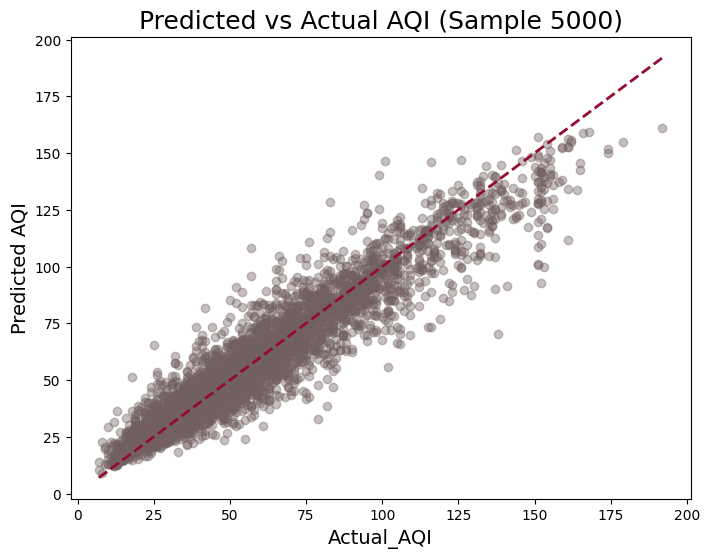

In [ ]:
plot_df = pd.DataFrame({"actual": y_sample_actual, "predicted": y_sample_pred})

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual"], plot_df["predicted"], alpha=0.4, color="#726060")
# y=x
plt.plot(
    [plot_df["actual"].min(), plot_df["actual"].max()],
    [plot_df["actual"].min(), plot_df["actual"].max()],
    linestyle="--",
    linewidth=2,
    color="#940B2E"
)
plt.title("Predicted vs Actual AQI (Sample 5000)", fontsize=18)
plt.xlabel("Actual_AQI", fontsize=14)
plt.ylabel("Predicted AQI", fontsize=14)
plt.show()

#### 📌 04-2 Line Plot — First 300 Samples Comparison

This line plot compares the first 300 actual vs predicted AQI values to visualize local fluctuations and trends.

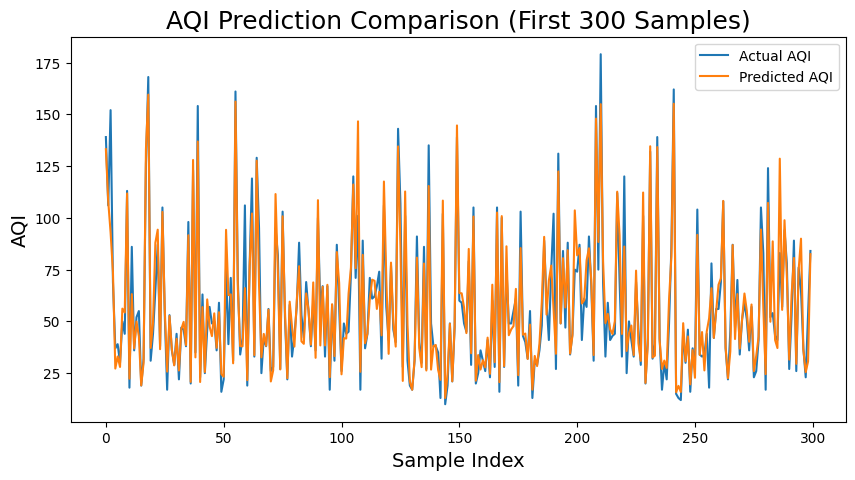

In [36]:
plt.figure(figsize=(10,5))
plt.plot(y_sample_actual.values[:300], label="Actual AQI")
plt.plot(y_sample_pred[:300], label="Predicted AQI")
plt.title("AQI Prediction Comparison (First 300 Samples)", fontsize=18)
plt.xlabel("Sample Index", fontsize=14)
plt.ylabel("AQI", fontsize=14)
plt.legend()
plt.show()

### 📝 Step 04 Summary — Visualization Insights  
In this step, we compared the model’s predictions against the actual AQI values using two visualization approaches:

1. **Scatter Plot (Sample 5000)**  
   - Points are closely aligned along the diagonal reference line, indicating that the model generally predicts AQI accurately.  
   - The spread increases slightly as AQI levels increase, suggesting a bit more variance at higher pollution values — a common characteristic in environmental data.  
   - Overall, the pattern shows strong correlation and low bias.

2. **Line Plot (First 300 Samples)**  
   - The predicted AQI curve closely follows the actual AQI curve, capturing local fluctuations and peaks effectively.  
   - The model is responsive to sharp changes and does not lag behind the actual measurements.  
   - This confirms that the model performs well not only in overall accuracy but also in short-term variability.

**Takeaway:**  
Both visualizations demonstrate that the Random Forest model produces stable and reliable predictions across a wide range of AQI levels.


### 🩺 Step 05 — Residual Analysis  

In this step, we analyze the model’s prediction errors (residuals) to evaluate whether the Random Forest model exhibits systematic bias or instability across different AQI levels.  
Residual analysis helps us understand how accurately the model captures underlying patterns and whether any structural issues remain in the predictions.

Since the test dataset contains over a million records, we will again use a **sample of 5,000 rows** for visualization to ensure clear, readable plots and efficient rendering performance.

In [62]:
import seaborn as sns

In [37]:
res_df = pd.DataFrame({
    "actual": y_sample_actual,
    "predicted": y_sample_pred
    })

res_df["residual"] = res_df["actual"] - res_df["predicted"]
res_df.head()

,actual,predicted,residual
5719042,139.0,133.145096,5.854904
1211696,106.0,107.947483,-1.947483
5183762,152.0,92.921325,59.078675
4842354,69.0,73.847785,-4.847785
688480,37.0,27.223178,9.776822


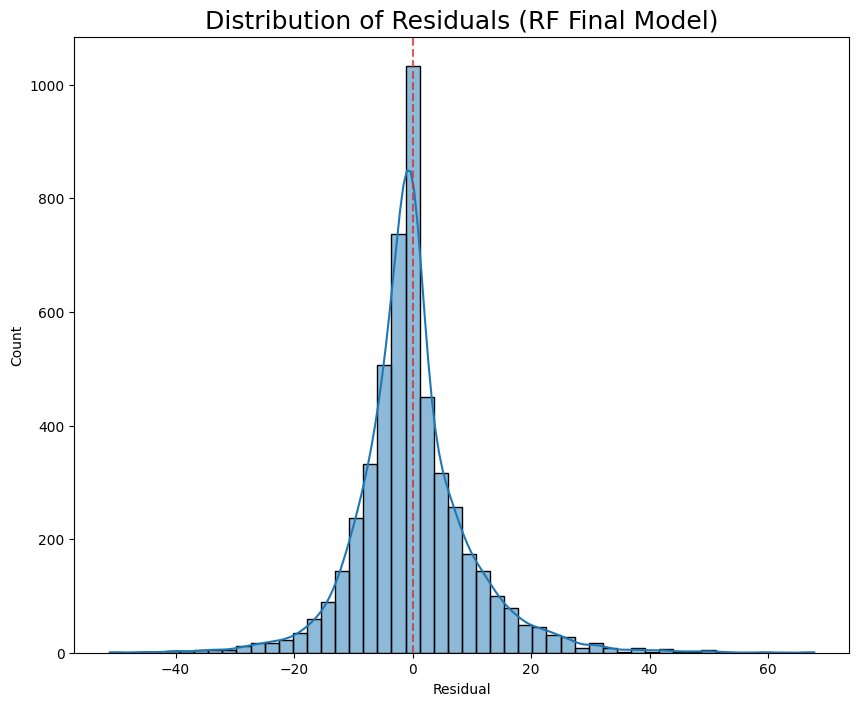

In [63]:
plt.figure(figsize=(10,8))

sns.histplot(res_df["residual"], bins=50, kde=True)
plt.axvline(0, linestyle="--", color="#C93434C8")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of Residuals (RF Final Model)", fontsize=18)
plt.grid(visible=False)
plt.show()

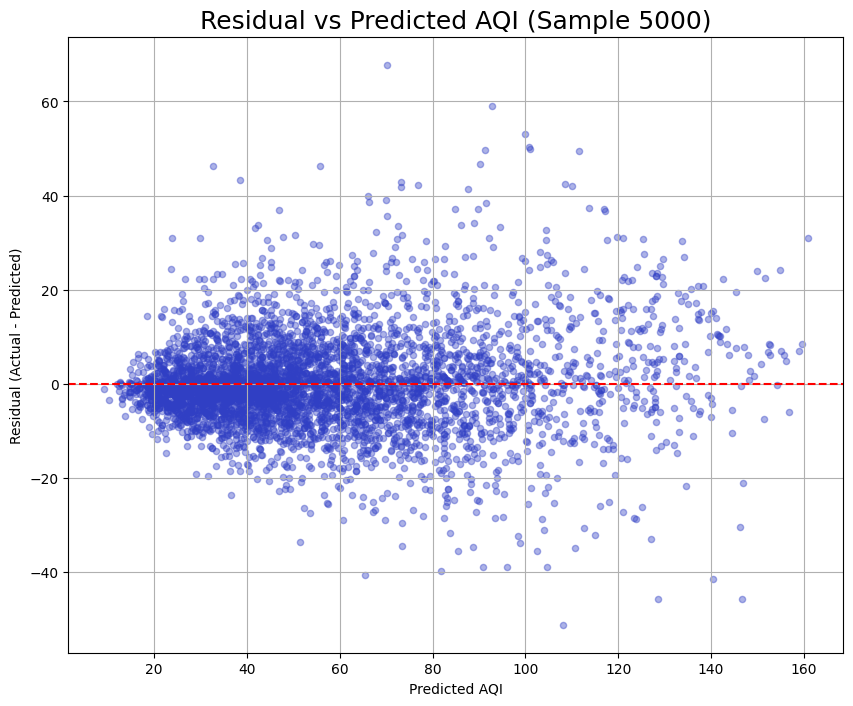

In [56]:
plt.figure(figsize=(10,8))

plt.scatter(
    x=res_df["predicted"],
    y=res_df["residual"],
    alpha=0.4,
    s=20,
    color="#303fc4"
)

plt.axhline(0, linestyle="--", color="red")

plt.xlabel("Predicted AQI")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted AQI (Sample 5000)", fontsize=18)
plt.grid(visible=True)
plt.show()

### 📝 Step 05 Summary — Residual Analysis Insights  

In this step, we examined the model’s prediction errors (residuals) using two diagnostic plots: the residual distribution and the residual–versus–predicted scatter plot.

1. **Residual Distribution (Histogram)**  
   - The residuals are centered closely around zero, indicating that the model does not systematically overestimate or underestimate AQI.  
   - The distribution resembles a bell-shaped curve with slightly heavier tails, which is typical for environmental data where high-AQI events exhibit stronger variability.  
   - Most residuals fall between **–20 and +20**, showing generally small errors with only a few larger deviations.

2. **Residual vs Predicted Scatter**  
   - The residuals appear randomly scattered around the zero line without clear patterns (no U-shape or funnel-shaped structure). This suggests that the model captures the general relationship well and does not suffer from major non-linear bias.  
   - As predicted AQI increases, the variance of residuals becomes slightly wider—this is expected because higher pollution levels naturally introduce more uncertainty.  
   - There is no obvious clustering or systematic drift, confirming that the model is stable across different AQI ranges.

**Takeaway:**  
Overall, the residual analysis indicates that the Random Forest model performs reliably, with no severe bias and only moderate variability at high AQI levels. The model is well-calibrated and shows robust prediction behavior across most of the AQI spectrum.


### 🎯 Step 06 — Export Prediction Results

In this step, we export the model’s prediction results so they can be reused for future model comparison, external analysis, and reporting.

Since we plan to evaluate and compare future models (e.g., XGBoost, LightGBM, neural networks), we will save the **full test set predictions** to a CSV file.  

This file will include both the actual AQI and the predicted AQI from the current Random Forest model, making it easy to track performance across different model versions.

In [57]:
from src.config import PREDICTION_DIR

In [59]:
# full prediction
y_pred_full = rf_model.predict(X_test)

full_pred_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_full
})

full_output_path = PREDICTION_DIR / "predictions_rf_full.csv"
full_pred_df.to_csv(full_output_path, index=False)
data(f"Full prediction CSV saved to: {full_output_path}")

📊 Full prediction CSV saved to: C:\Users\dinni\OneDrive\桌面\air_pollution\output\predictions\predictions_rf_full.csv


In [60]:
# sample prediction
sample_pred_df = pd.DataFrame({
    "actual": y_sample_actual.values,
    "predicted": y_sample_pred
})

sample_output_path = PREDICTION_DIR / "predictions_rf_sample5000.csv"
sample_pred_df.to_csv(sample_output_path, index=False)
save(f"Sample prediction CSV saved to: {sample_output_path}")

💾 Sample prediction CSV saved to: C:\Users\dinni\OneDrive\桌面\air_pollution\output\predictions\predictions_rf_sample5000.csv


### 📝 Step 06 Summary

In this step, we exported the prediction results to CSV files. The full dataset allows comprehensive evaluation and integration into dashboards, while the sample dataset provides a lightweight version for quick exploration and visualization.

### 🔮 Chapter 07 Summary

In Chapter 07, we evaluated the final Random Forest model using both full test-set metrics and sampled visual diagnostics. The model demonstrated strong predictive performance, achieving low MAE/RMSE and a high R² score across over one million test samples. Visualization results show that predicted AQI values align closely with actual observations, while residual analysis confirms stable behavior with no major systematic bias.

The scatter plot indicates that most predictions fall near the ideal diagonal line, reflecting accurate estimation across a wide AQI range. The line plot (first 300 samples) displays close tracking of short-term fluctuations, suggesting the model successfully captures local patterns. The residual distribution is centered near zero, and residual-vs-predicted scatter shows random dispersion, indicating that errors are well-behaved and that the model does not suffer from structural issues or nonlinear underfitting.

Overall, the final model is reliable, stable, and well-calibrated — suitable for AQI prediction, downstream analysis, and even real-time inference tools.